## Setup

This cell imports required libraries for EDA and defines the paths to the raw and processed data directories.


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PLOT_DIR = ROOT / "plots" / "eda"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

## Data Loading

This cell reads the raw training dataset for exploratory analysis.


In [16]:
raw_path = RAW_DIR / "train.csv"
raw_df = pd.read_csv(raw_path)

In [17]:
print("Number of rows:", raw_df.shape[0])
print("Number of columns:", raw_df.shape[1])


Number of rows: 574945
Number of columns: 341


## Missing Value Analysis

This cell computes and displays the percentage of missing values for each feature.


In [18]:
missing_ratio = raw_df.isnull().mean() * 100
missing_ratio[missing_ratio > 0].sort_values(ascending=False)


thm_5        5.789423
tof_5_v63    5.242588
tof_5_v24    5.242588
tof_5_v18    5.242588
tof_5_v19    5.242588
               ...   
tof_2_v36    1.082538
rot_x        0.642148
rot_z        0.642148
rot_y        0.642148
rot_w        0.642148
Length: 329, dtype: float64

## Missing Value Visualization

This cell plots the top 20 features with the highest percentage of missing values.


Saved plot to: E:\test\plots\eda\missing_values_top_20.png


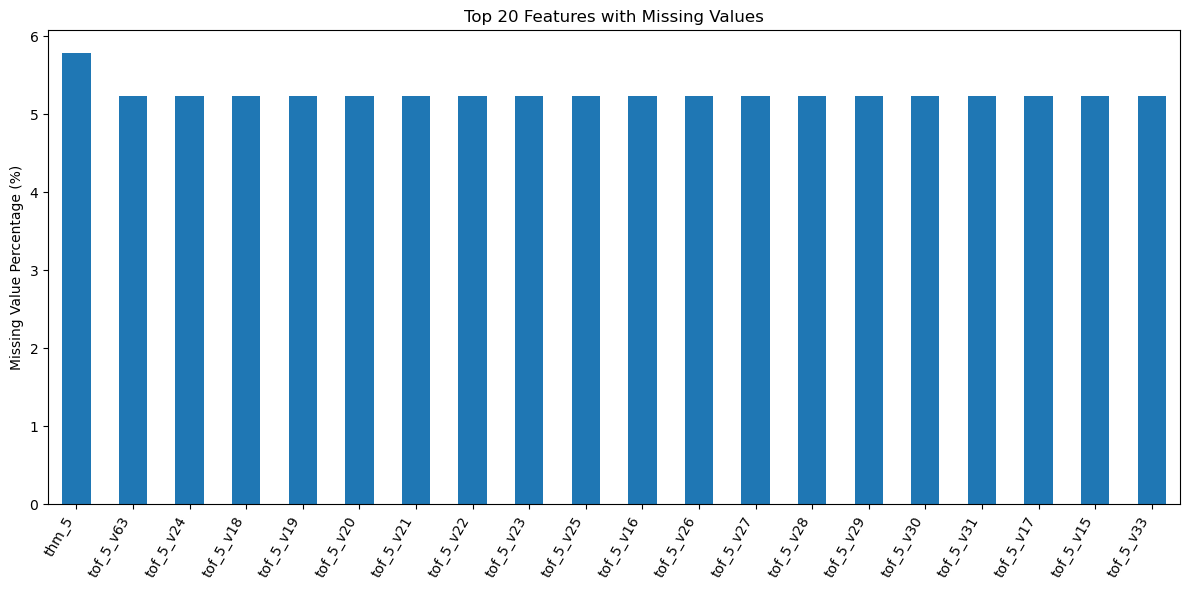

In [19]:



missing_nonzero = missing_ratio[missing_ratio > 0].sort_values(ascending=False)


top_n = 20
missing_to_plot = missing_nonzero.head(top_n)

plt.figure(figsize=(12,6))
missing_to_plot.plot(kind="bar")

plt.ylabel("Missing Value Percentage (%)")
plt.title(f"Top {top_n} Features with Missing Values")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
save_path = PLOT_DIR / "missing_values_top_20.png"
plt.savefig(save_path)
print(f"Saved plot to: {save_path}")
plt.show()



## Missing Values by Sensor Group

This cell calculates and visualizes the average missing value percentage for IMU, Thermopile, and TOF sensors.


Saved plot to: E:\test\plots\eda\missing_values_by_sensor.png


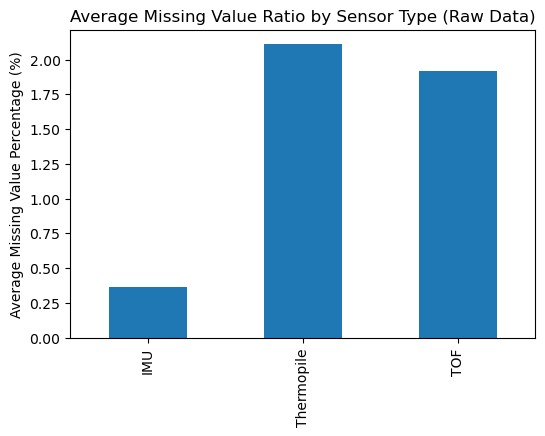

In [20]:
imu_cols = [c for c in raw_df.columns if c.startswith("acc_") or c.startswith("rot_")]
thm_cols = [c for c in raw_df.columns if c.startswith("thm_")]
tof_cols = [c for c in raw_df.columns if c.startswith("tof_")]

avg_missing = {
    "IMU": raw_df[imu_cols].isnull().mean().mean() * 100,
    "Thermopile": raw_df[thm_cols].isnull().mean().mean() * 100,
    "TOF": raw_df[tof_cols].isnull().mean().mean() * 100
}

pd.Series(avg_missing).plot(kind="bar", figsize=(6,4))
plt.ylabel("Average Missing Value Percentage (%)")
plt.title("Average Missing Value Ratio by Sensor Type (Raw Data)")
save_path = PLOT_DIR / "missing_values_by_sensor.png"
plt.savefig(save_path)
print(f"Saved plot to: {save_path}")
plt.show()


## Row Missing Ratio

This cell calculates the percentage of rows that contain at least one missing value.


In [21]:
rows_with_null = raw_df.isnull().any(axis=1)

# compute the ratio
row_missing_percentage = rows_with_null.mean() * 100

row_missing_percentage


6.720642844098131

## Sequence Length Calculation

This cell computes the number of rows per `sequence_id` to examine sequence lengths.


In [22]:
seq_lengths = raw_df.groupby("sequence_id").size()

seq_lengths.head()


sequence_id
SEQ_000007    57
SEQ_000008    68
SEQ_000013    53
SEQ_000016    61
SEQ_000018    54
dtype: int64

In [23]:
seq_lengths.describe()


count    8151.000000
mean       70.536744
std        35.389879
min        29.000000
25%        51.000000
50%        59.000000
75%        78.000000
max       700.000000
dtype: float64

## Sequence Length Distribution

This histogram shows how sequence lengths are distributed in the raw dataset.


Saved plot to: E:\test\plots\eda\sequence_length_dist_raw.png


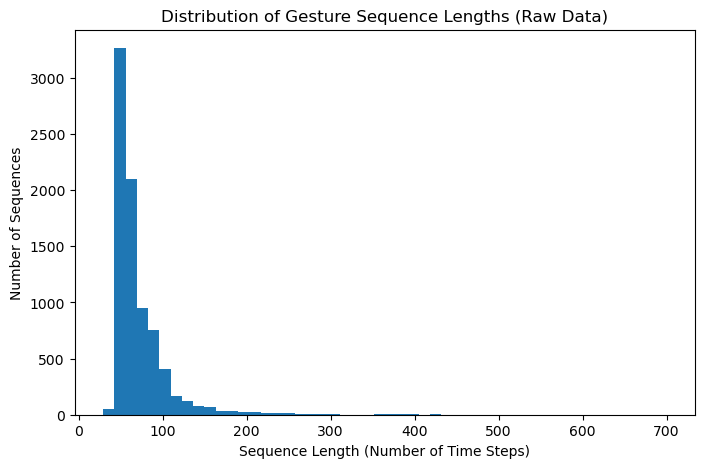

In [24]:
plt.figure(figsize=(8,5))
plt.hist(seq_lengths, bins=50)
plt.xlabel("Sequence Length (Number of Time Steps)")
plt.ylabel("Number of Sequences")
plt.title("Distribution of Gesture Sequence Lengths (Raw Data)")
save_path = PLOT_DIR / "sequence_length_dist_raw.png"
plt.savefig(save_path)
print(f"Saved plot to: {save_path}")
plt.show()


## Load Processed Data

This cell reads the cleaned dataset for further analysis.


In [25]:
clean_path = PROCESSED_DIR / "train_cleaned.csv"
clean_df = pd.read_csv(clean_path)

In [26]:
print("Raw rows:", raw_df.shape[0])
print("Cleaned rows:", clean_df.shape[0])

print("Raw sequences:", raw_df["sequence_id"].nunique())
print("Cleaned sequences:", clean_df["sequence_id"].nunique())


Raw rows: 574945
Cleaned rows: 536115
Raw sequences: 8151
Cleaned sequences: 7588


## Raw vs Cleaned Sequence Lengths

This cell calculates sequence lengths for both raw and cleaned datasets to enable comparison.


In [27]:
raw_seq_len = raw_df.groupby("sequence_id").size()
clean_seq_len = clean_df.groupby("sequence_id").size()


## Raw vs Cleaned Distribution

This histogram compares sequence length distributions before and after preprocessing.


Saved plot to: E:\test\plots\eda\sequence_length_comparison.png


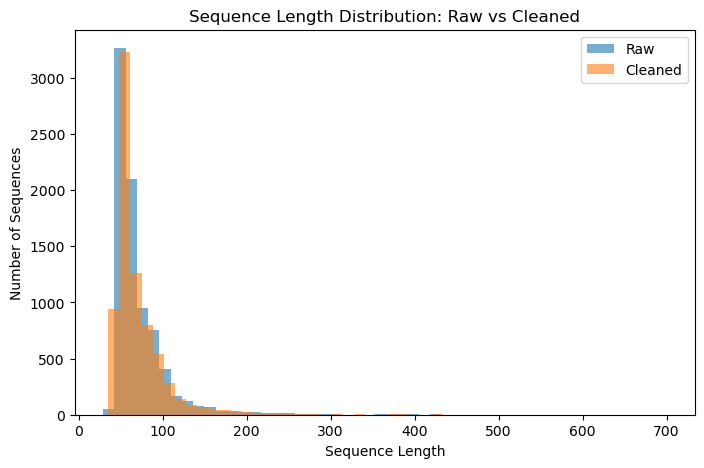

In [28]:
plt.figure(figsize=(8,5))
plt.hist(raw_seq_len, bins=50, alpha=0.6, label="Raw")
plt.hist(clean_seq_len, bins=50, alpha=0.6, label="Cleaned")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Sequences")
plt.title("Sequence Length Distribution: Raw vs Cleaned")
plt.legend()
save_path = PLOT_DIR / "sequence_length_comparison.png"
plt.savefig(save_path)
print(f"Saved plot to: {save_path}")
plt.show()
